In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)

X = pd.read_parquet("data/X_top20.parquet")
y = pd.read_parquet("data/y_binary.parquet")["BinaryLabel"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (9546, 20)
y distribution:
 BinaryLabel
0    5976
1    3570
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (7636, 20)
Test size: (1910, 20)


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "XGBoost":       XGBClassifier(n_estimators=100, max_depth=6,
                                   eval_metric="logloss", random_state=42, n_jobs=-1),
    "Linear SVM":    LinearSVC(C=1.0, max_iter=2000, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [4]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)

    results[name] = {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1":        round(f1_score(y_test, y_pred), 4),
        "FPR":       round(fpr, 4)
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Benign","Attack"]))

results_df = pd.DataFrame(results).T
print(results_df)
results_df.to_csv("outputs/model_results.csv")


=== Decision Tree ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      1196
      Attack       1.00      1.00      1.00       714

    accuracy                           1.00      1910
   macro avg       1.00      1.00      1.00      1910
weighted avg       1.00      1.00      1.00      1910


=== XGBoost ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      1196
      Attack       1.00      1.00      1.00       714

    accuracy                           1.00      1910
   macro avg       1.00      1.00      1.00      1910
weighted avg       1.00      1.00      1.00      1910


=== Linear SVM ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      1196
      Attack       0.99      1.00      1.00       714

    accuracy                           1.00      1910
   macro avg       1.00      1.00      1.00      1910
weighted avg  

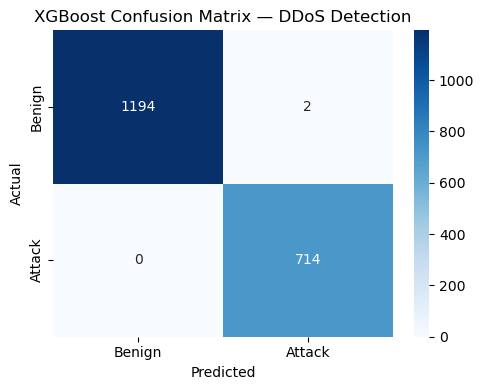

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = models["XGBoost"]
y_pred_xgb = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Attack"],
            yticklabels=["Benign","Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix — DDoS Detection")
plt.tight_layout()
plt.savefig("outputs/08_confusion_matrix_xgb.png", dpi=150)
plt.show()

In [6]:
import joblib
joblib.dump(best_model, "models/ddos_xgboost.pkl")
print("Saved: models/ddos_xgboost.pkl")

Saved: models/ddos_xgboost.pkl


In [13]:
# Leakage Check 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Overall separability via Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_proba = lr.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Logistic Regression AUC: {auc:.4f}")
if auc >= 0.999:
    print("Near-perfect AUC — possible data leakage, review features")
else:
    print("AUC looks realistic — no obvious leakage detected")

# Per-feature separability (top 10)
print("\nPer-feature AUC (top 10):")
for col in X_train.columns[:10]:
    auc_single = roc_auc_score(y_test, X_test[col])
    flag = " possible leakage" if auc_single >= 0.999 else ""
    print(f"  {col}: {auc_single:.4f}{flag}")


Logistic Regression AUC: 0.9998
Near-perfect AUC — possible data leakage, review features

Per-feature AUC (top 10):
  Packet Length Min: 0.9998 possible leakage
  Fwd Packet Length Min: 0.9987
  Avg Packet Size: 0.9950
  Avg Fwd Segment Size: 0.9967
  Fwd Packet Length Mean: 0.9967
  Packet Length Mean: 0.9931
  Fwd Packet Length Max: 0.9703
  Protocol: 0.8691
  Flow Bytes/s: 0.9916
  Packet Length Max: 0.9109


In [9]:
# Stress test — train only on Benign + LDAP, test on DrDoS_LDAP + NetBIOS
# Simulates domain shift (new attack types)

import pandas as pd
import numpy as np
import joblib

train = pd.read_parquet("./data/LDAP-training.parquet")
test = pd.read_parquet("./data/LDAP-testing.parquet")
df = pd.concat([train, test], ignore_index=True)
df["BinaryLabel"] = (df["Label"] != "Benign").astype(int)

print("Labels:", df["Label"].value_counts())


Labels: Label
Benign        5976
LDAP          1884
DrDoS_LDAP    1440
NetBIOS        246
Name: count, dtype: int64


In [10]:
top20_cols = joblib.load("models/top20_features.pkl")

train_data = df[df["Label"].isin(["Benign", "LDAP"])]
test_data  = df[df["Label"].isin(["DrDoS_LDAP", "NetBIOS", "Benign"])]

X_train_s = train_data[top20_cols]
y_train_s = train_data["BinaryLabel"]

X_test_s = test_data[top20_cols]
y_test_s = test_data["BinaryLabel"]

print("Train shape:", X_train_s.shape)
print("Test shape:", X_test_s.shape)

Train shape: (7860, 20)
Test shape: (7662, 20)


In [11]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train_s)
X_test_sc  = sc.transform(X_test_s)

print("Scaling done.")

Scaling done.


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

xgb_s = XGBClassifier(n_estimators=100, max_depth=6, random_state=42)
xgb_s.fit(X_train_sc, y_train_s)

y_pred_s = xgb_s.predict(X_test_sc)

print("Stress Test — Unseen Attack Types:")
print(classification_report(y_test_s, y_pred_s, target_names=["Benign","Attack"]))
print("F1:", round(f1_score(y_test_s, y_pred_s), 4))


Stress Test — Unseen Attack Types:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.98      5976
      Attack       1.00      0.89      0.94      1686

    accuracy                           0.98      7662
   macro avg       0.98      0.94      0.96      7662
weighted avg       0.98      0.98      0.97      7662

F1: 0.941
